# Estudio y comparativa resultados distributed

En este notebook vamos a analizar los resultados de la versión distribuida basada en complejidad. En particular, hemos ejecutado 2 métodos. Los dos se basan en tomar muestras bootstrap de variables e ir evaluando la complejidad siguiendo un esquema backward. La manera de elegir qué variable sale en cada paso puede ser:
- Random choice. Como el propio nombre indica, se escoge aleatoriamente.
- Complexity guided. Se va sacando la variable que mayor complejidad aporta en base al ranking univariante. En este tenemos menos esperanzas porque cuando hemos hecho el estudio forward esa ha sido la guía y los resultados no han sido buenos.

Aquí vamos tanto a estudiar los resultados de esta primera aproximación distribuidad como a comparar su performance tanto en complejidad como en rendimiento con los métodos del SOTA. En todos los casos vamos a escoger el número k de variables como el número de variables informativas (sabemos cuál es porque estamos en el caso artificial). En nuestra versión distribuida hemos hecho un filtro previo de variables con correlación de Pearson superior a 0.9. Así, para que las comparaciones sean justas, hemos ejecutado los métodos del estado del arte tanto sin el filtro como con el filtro. Los métodos del SOTA con filtro tendrán un "_corr" en el nombre.

In [1]:
import copy
from sklearn import preprocessing
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from skrebate import ReliefF
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import glob
import re
from DistributedFS_Complexity import *

In [2]:
import os
os.chdir("..")
root_path = os.getcwd()

### Resultados distributed

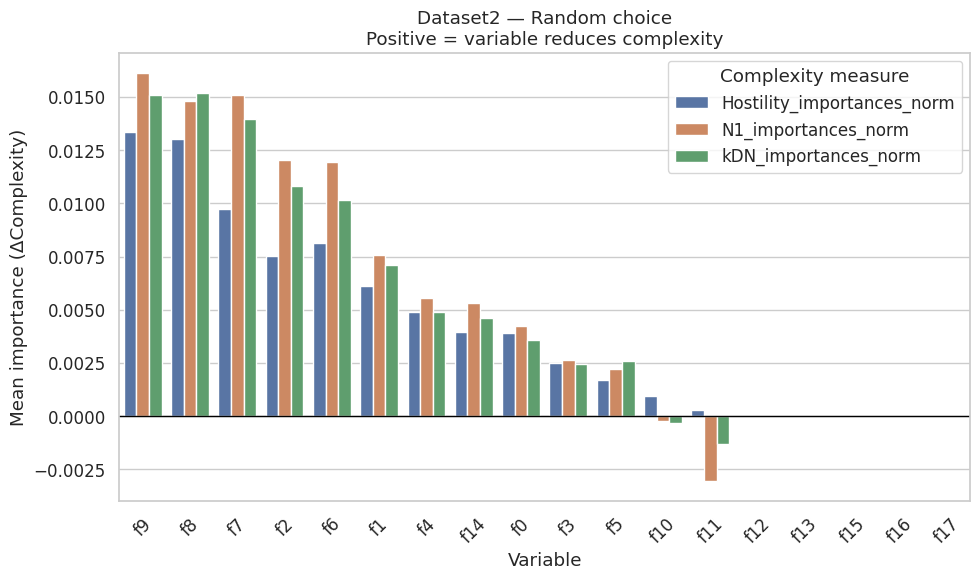

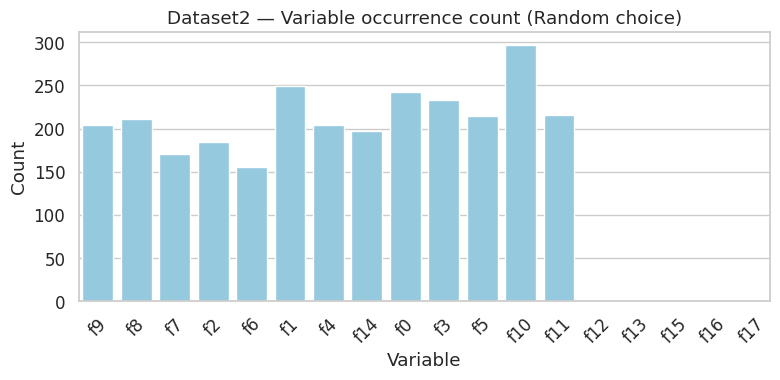

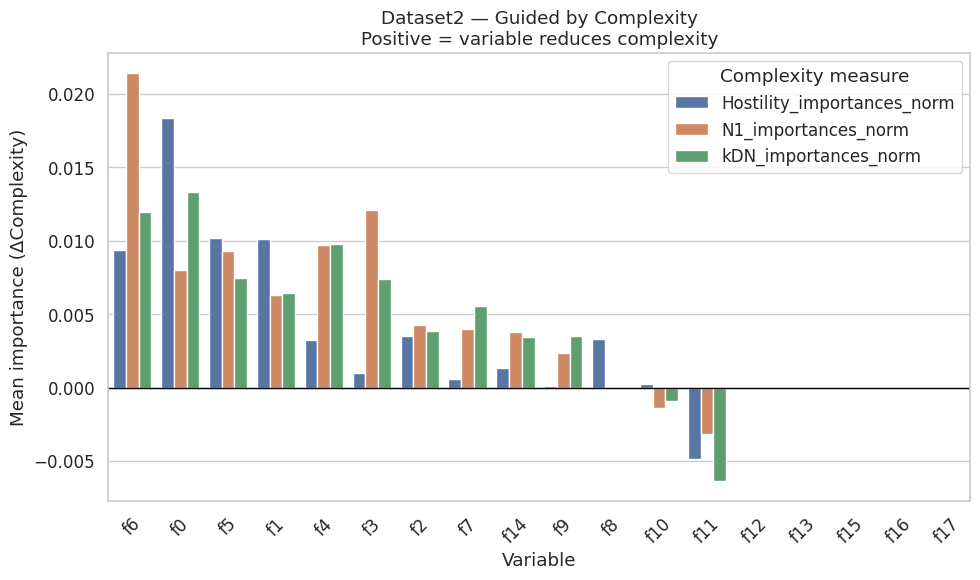

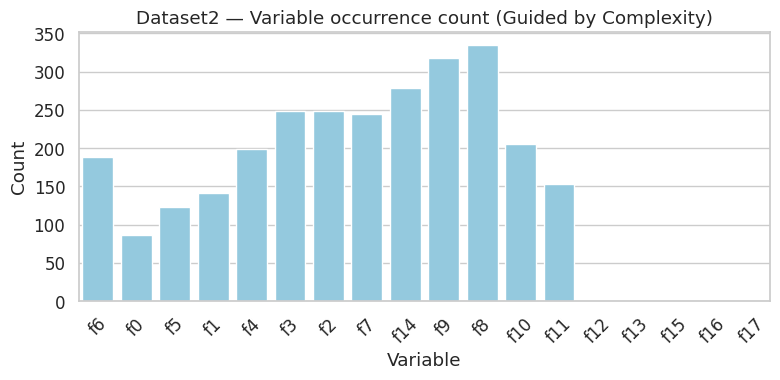

----------------- Spearman correlation random choice -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.989011,0.983516
N1_importances_norm,0.989011,1.000000,0.978022
kDN_importances_norm,0.983516,0.978022,1.000000


----------------- Spearman correlation complexity guided -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.609890,0.708791
N1_importances_norm,0.609890,1.000000,0.917582
kDN_importances_norm,0.708791,0.917582,1.000000


In [3]:
# Dataset 2
df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset2_ComplexityRandomDistributed.csv", index_col=0)
df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset2_ComplexityGuidedDistributed.csv", index_col=0)


plot_complexity_importances(df_random, dataset_name="Dataset2", guided=False)
plot_complexity_importances(df_guided, dataset_name="Dataset2", guided=True)

corr_matrix = compute_spearman_correlations(df_random)
print('----------------- Spearman correlation random choice -----------------')
display(pd.DataFrame(corr_matrix))
corr_matrix_guided = compute_spearman_correlations(df_guided)
print('----------------- Spearman correlation complexity guided -----------------')
pd.DataFrame(corr_matrix_guided)

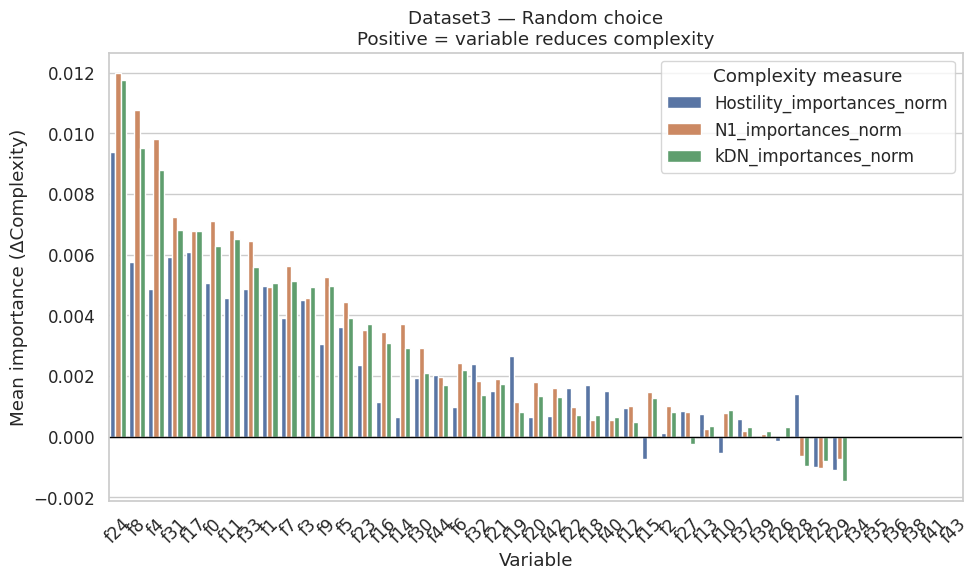

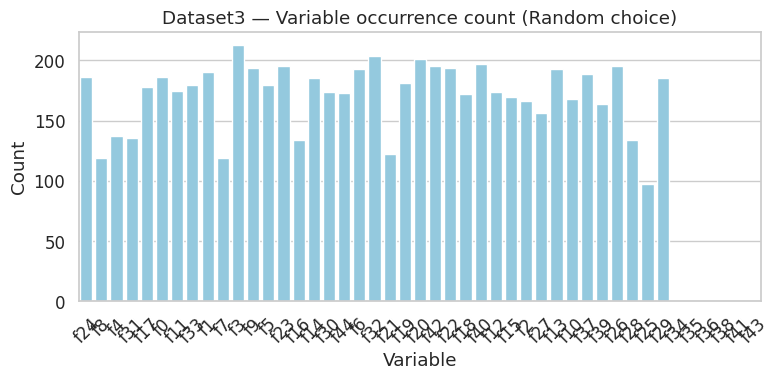

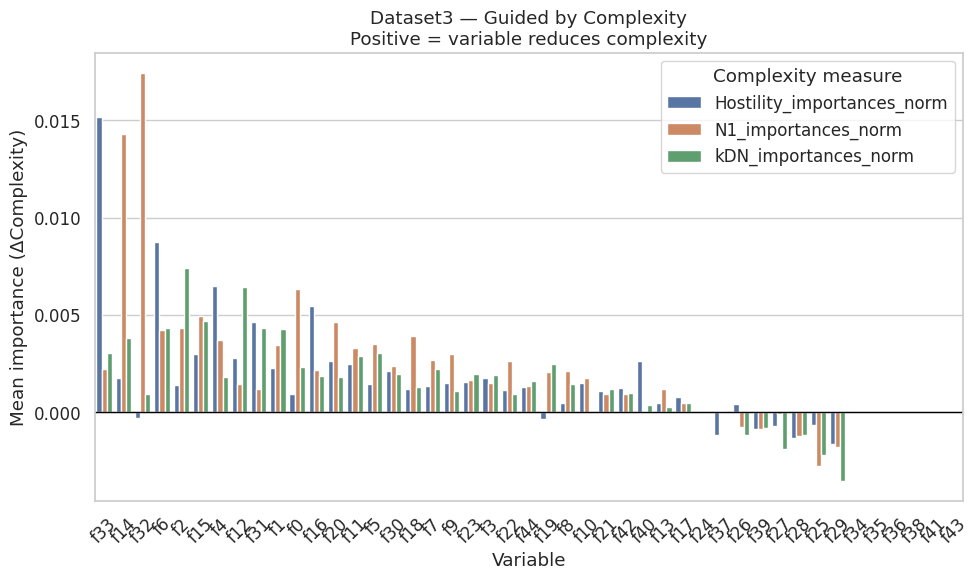

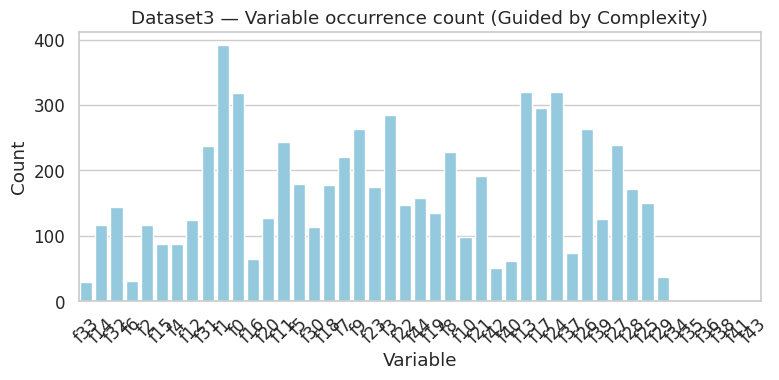

----------------- Spearman correlation random choice -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.840486,0.832794
N1_importances_norm,0.840486,1.000000,0.985628
kDN_importances_norm,0.832794,0.985628,1.000000


----------------- Spearman correlation complexity guided -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.527733,0.723482
N1_importances_norm,0.527733,1.000000,0.698178
kDN_importances_norm,0.723482,0.698178,1.000000


In [4]:
# Dataset 3
df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset3_ComplexityRandomDistributed.csv", index_col=0)
df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset3_ComplexityGuidedDistributed.csv", index_col=0)


plot_complexity_importances(df_random, dataset_name="Dataset3", guided=False)
plot_complexity_importances(df_guided, dataset_name="Dataset3", guided=True)

corr_matrix = compute_spearman_correlations(df_random)
print('----------------- Spearman correlation random choice -----------------')
display(pd.DataFrame(corr_matrix))
corr_matrix_guided = compute_spearman_correlations(df_guided)
print('----------------- Spearman correlation complexity guided -----------------')
pd.DataFrame(corr_matrix_guided)

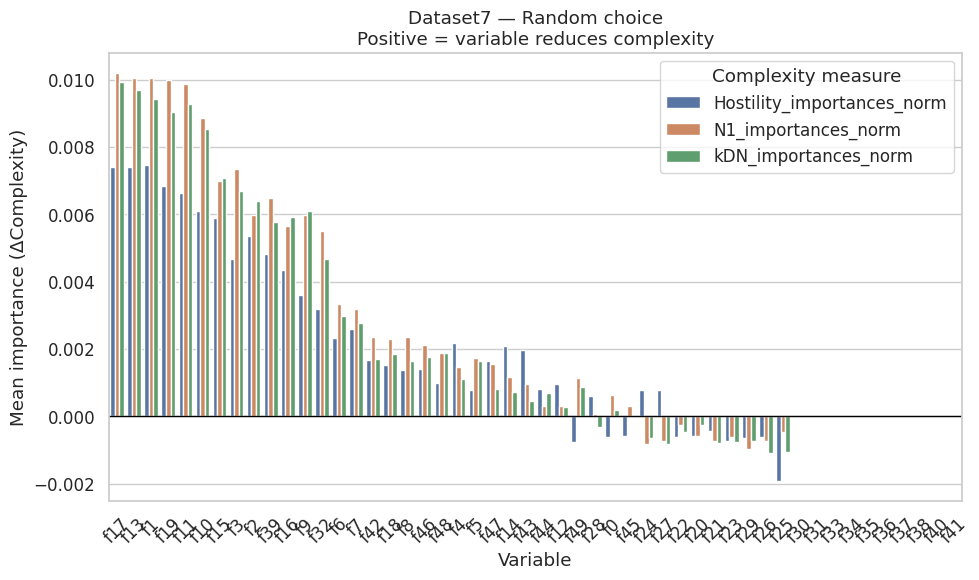

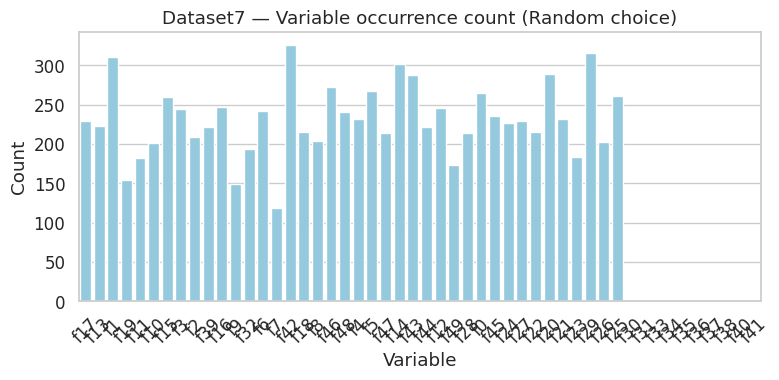

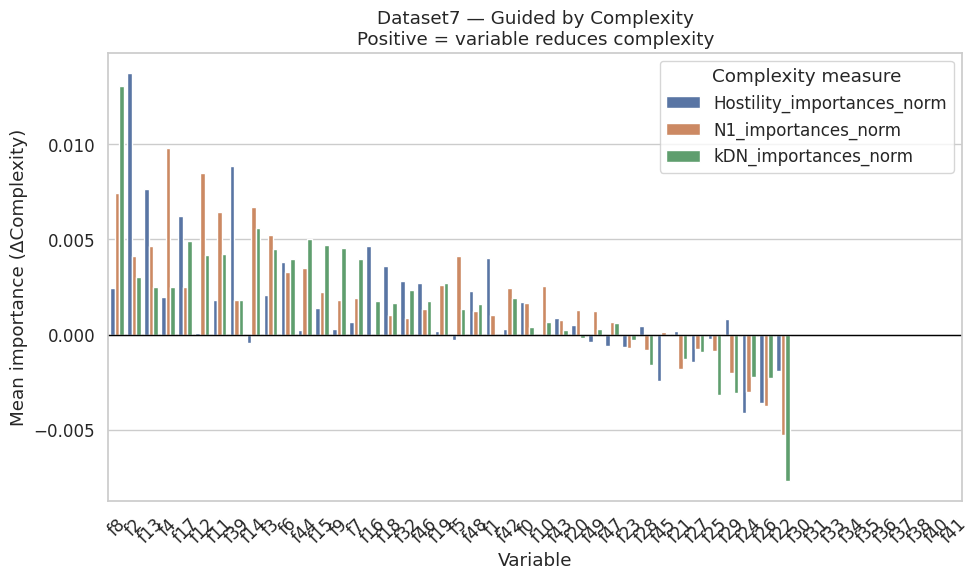

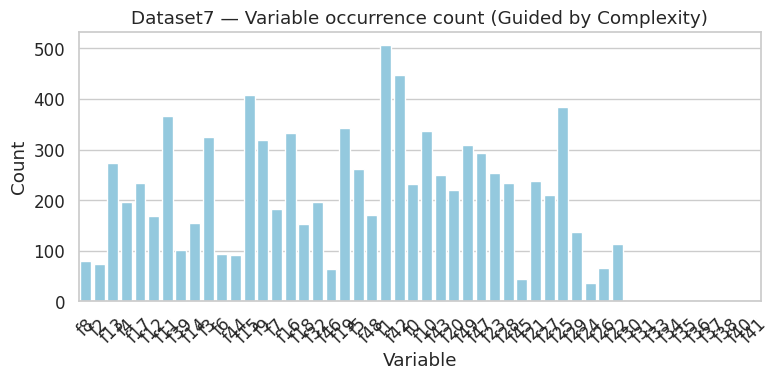

----------------- Spearman correlation random choice -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.908068,0.912383
N1_importances_norm,0.908068,1.000000,0.980300
kDN_importances_norm,0.912383,0.980300,1.000000


----------------- Spearman correlation complexity guided -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.389681,0.459475
N1_importances_norm,0.389681,1.000000,0.851032
kDN_importances_norm,0.459475,0.851032,1.000000


In [5]:
# Dataset 7
df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset7_ComplexityRandomDistributed.csv", index_col=0)
df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset7_ComplexityGuidedDistributed.csv", index_col=0)


plot_complexity_importances(df_random, dataset_name="Dataset7", guided=False)
plot_complexity_importances(df_guided, dataset_name="Dataset7", guided=True)

corr_matrix = compute_spearman_correlations(df_random)
print('----------------- Spearman correlation random choice -----------------')
display(pd.DataFrame(corr_matrix))
corr_matrix_guided = compute_spearman_correlations(df_guided)
print('----------------- Spearman correlation complexity guided -----------------')
pd.DataFrame(corr_matrix_guided)

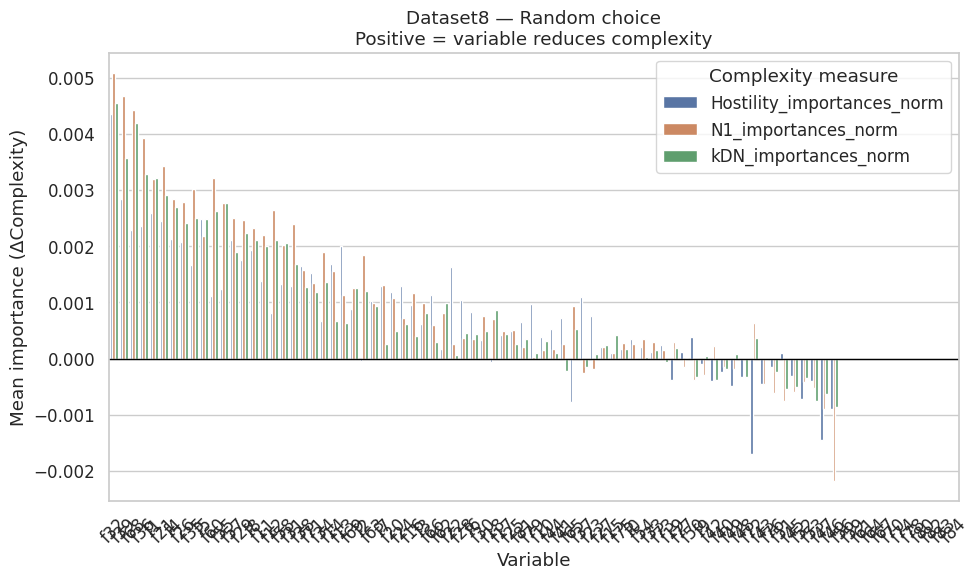

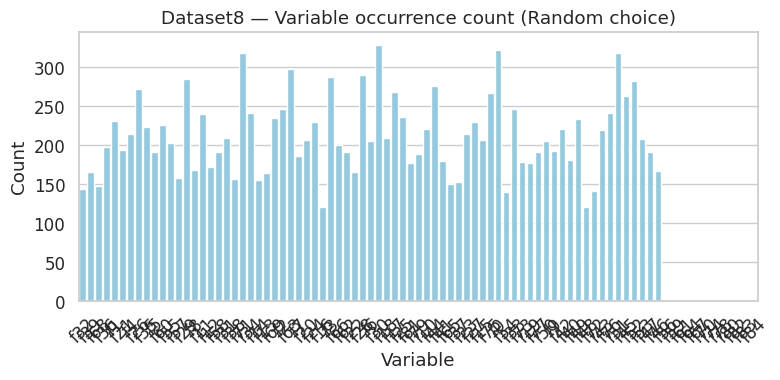

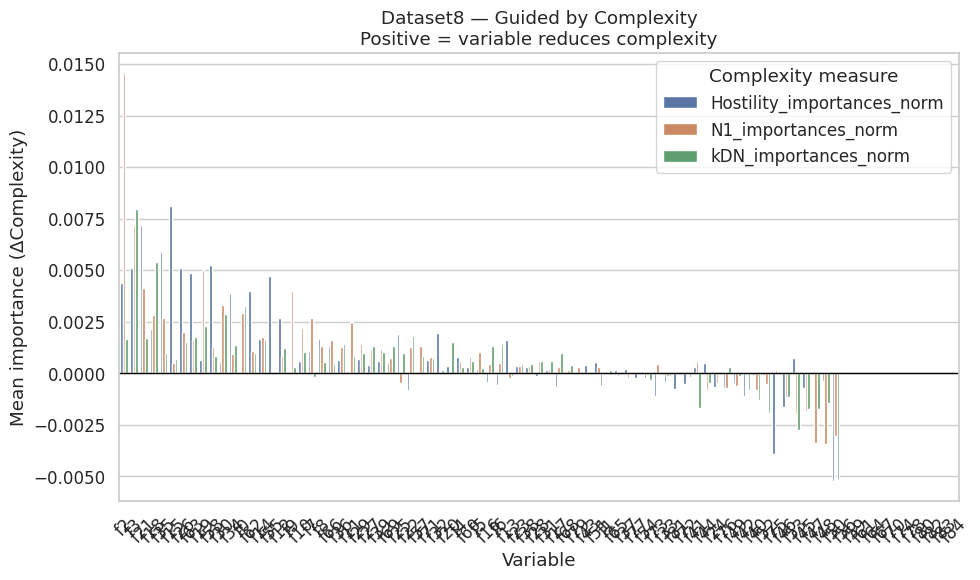

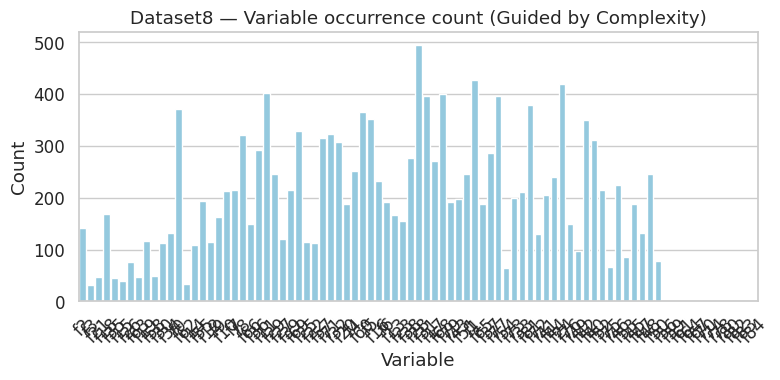

----------------- Spearman correlation random choice -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.786653,0.767864
N1_importances_norm,0.786653,1.000000,0.952302
kDN_importances_norm,0.767864,0.952302,1.000000


----------------- Spearman correlation complexity guided -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.523201,0.469795
N1_importances_norm,0.523201,1.000000,0.777058
kDN_importances_norm,0.469795,0.777058,1.000000


In [6]:
# Dataset 8
df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset8_ComplexityRandomDistributed.csv", index_col=0)
df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset8_ComplexityGuidedDistributed.csv", index_col=0)


plot_complexity_importances(df_random, dataset_name="Dataset8", guided=False)
plot_complexity_importances(df_guided, dataset_name="Dataset8", guided=True)

corr_matrix = compute_spearman_correlations(df_random)
print('----------------- Spearman correlation random choice -----------------')
display(pd.DataFrame(corr_matrix))
corr_matrix_guided = compute_spearman_correlations(df_guided)
print('----------------- Spearman correlation complexity guided -----------------')
pd.DataFrame(corr_matrix_guided)

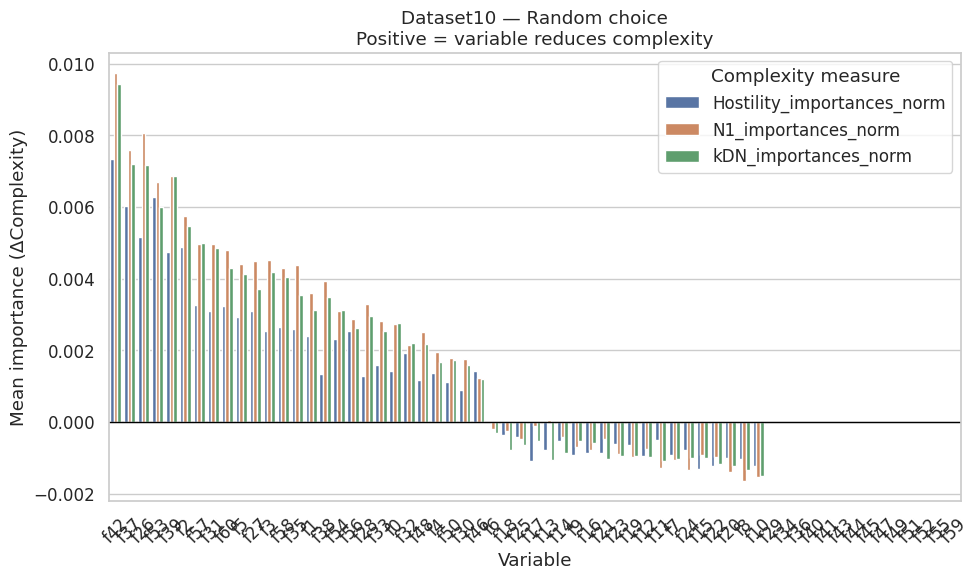

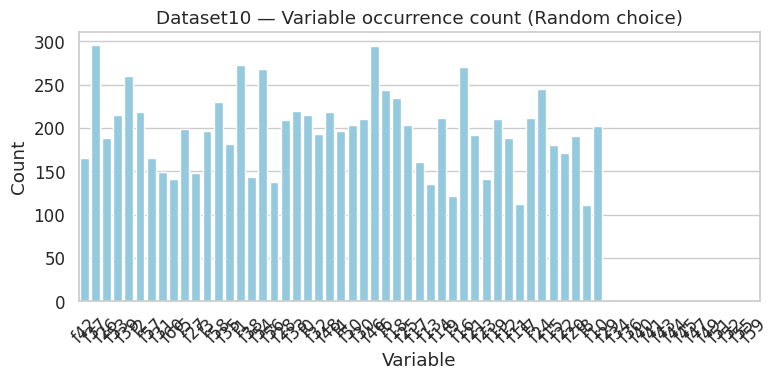

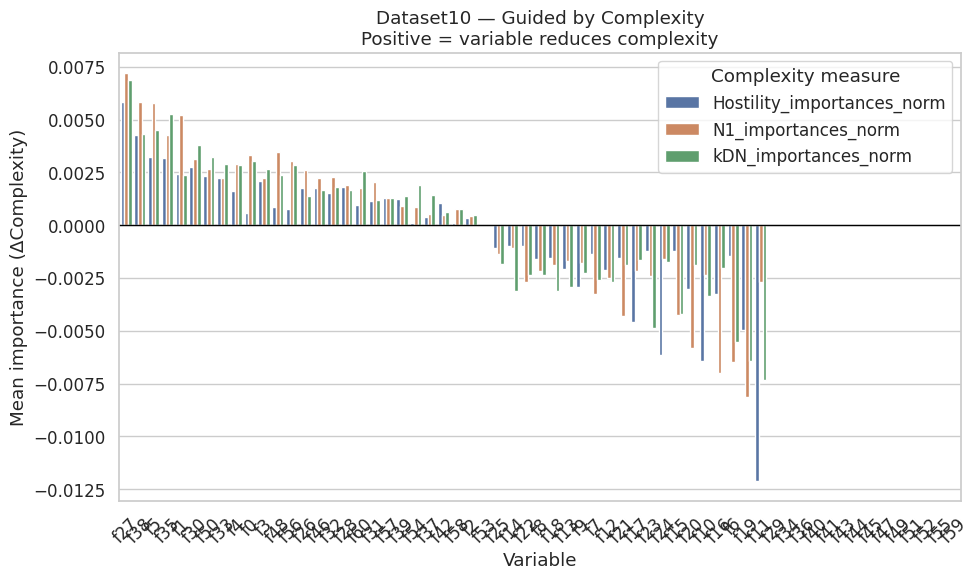

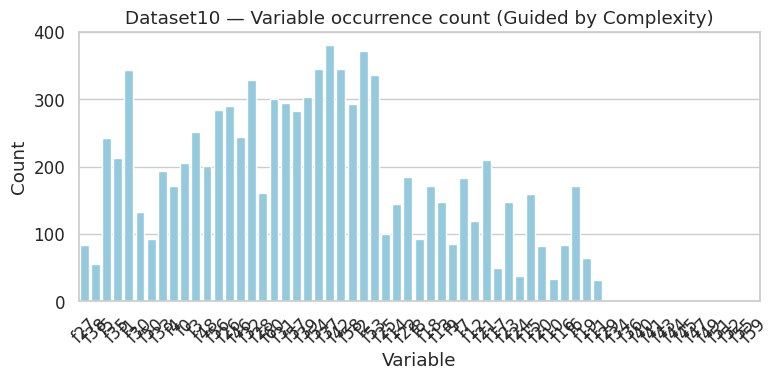

----------------- Spearman correlation random choice -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.939986,0.944843
N1_importances_norm,0.939986,1.000000,0.975370
kDN_importances_norm,0.944843,0.975370,1.000000


----------------- Spearman correlation complexity guided -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.883557,0.863899
N1_importances_norm,0.883557,1.000000,0.916397
kDN_importances_norm,0.863899,0.916397,1.000000


In [7]:
# Dataset 10
df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset10_ComplexityRandomDistributed.csv", index_col=0)
df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset10_ComplexityGuidedDistributed.csv", index_col=0)


plot_complexity_importances(df_random, dataset_name="Dataset10", guided=False)
plot_complexity_importances(df_guided, dataset_name="Dataset10", guided=True)

corr_matrix = compute_spearman_correlations(df_random)
print('----------------- Spearman correlation random choice -----------------')
display(pd.DataFrame(corr_matrix))
corr_matrix_guided = compute_spearman_correlations(df_guided)
print('----------------- Spearman correlation complexity guided -----------------')
pd.DataFrame(corr_matrix_guided)

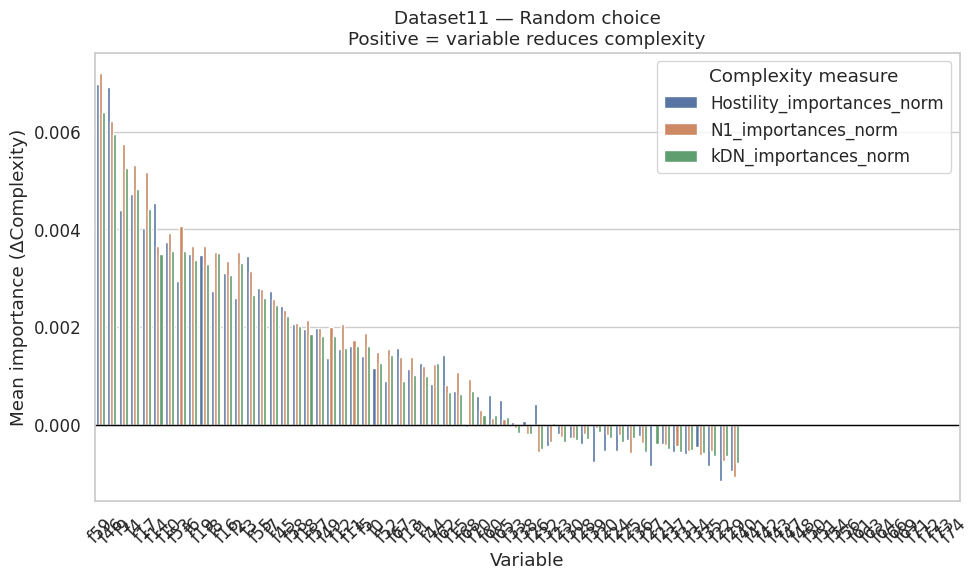

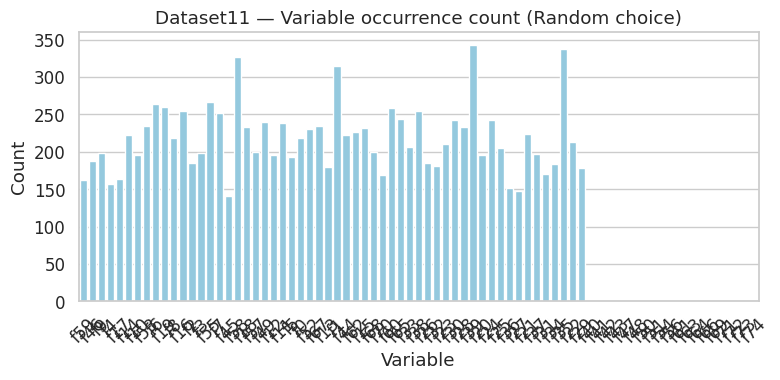

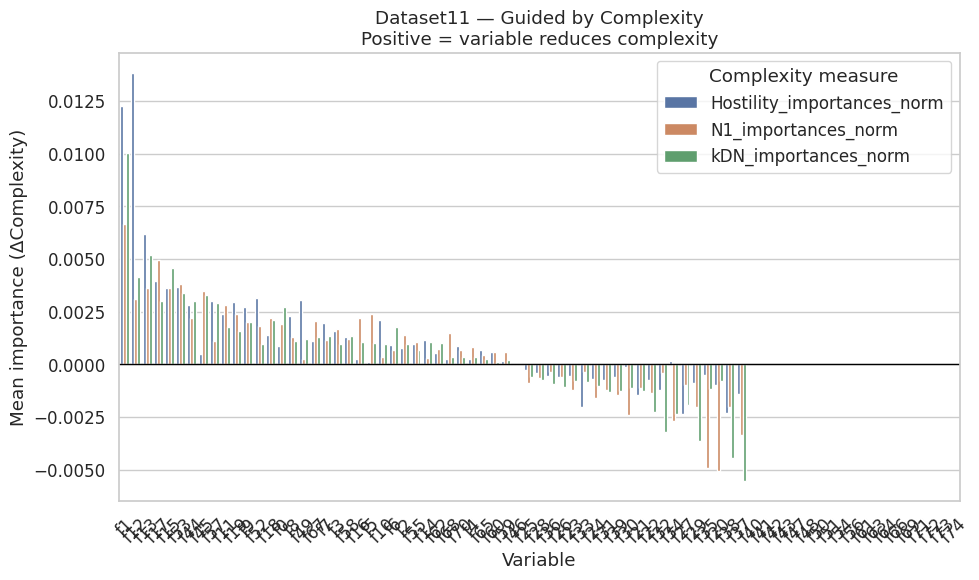

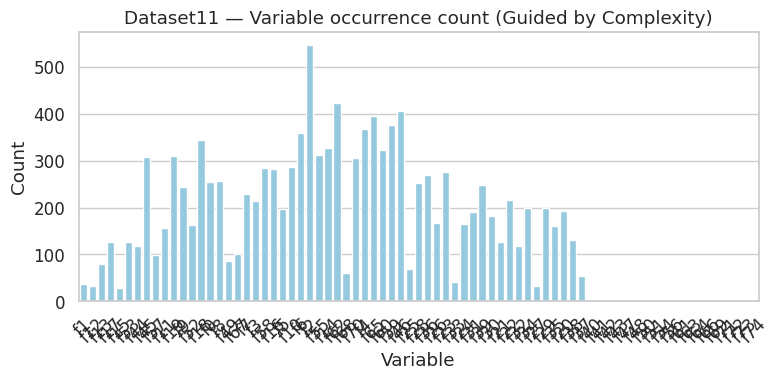

----------------- Spearman correlation random choice -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.950308,0.958373
N1_importances_norm,0.950308,1.000000,0.984074
kDN_importances_norm,0.958373,0.984074,1.000000


----------------- Spearman correlation complexity guided -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.808886,0.894327
N1_importances_norm,0.808886,1.000000,0.905400
kDN_importances_norm,0.894327,0.905400,1.000000


In [8]:
# Dataset 11
df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset11_ComplexityRandomDistributed.csv", index_col=0)
df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset11_ComplexityGuidedDistributed.csv", index_col=0)


plot_complexity_importances(df_random, dataset_name="Dataset11", guided=False)
plot_complexity_importances(df_guided, dataset_name="Dataset11", guided=True)

corr_matrix = compute_spearman_correlations(df_random)
print('----------------- Spearman correlation random choice -----------------')
display(pd.DataFrame(corr_matrix))
corr_matrix_guided = compute_spearman_correlations(df_guided)
print('----------------- Spearman correlation complexity guided -----------------')
pd.DataFrame(corr_matrix_guided)

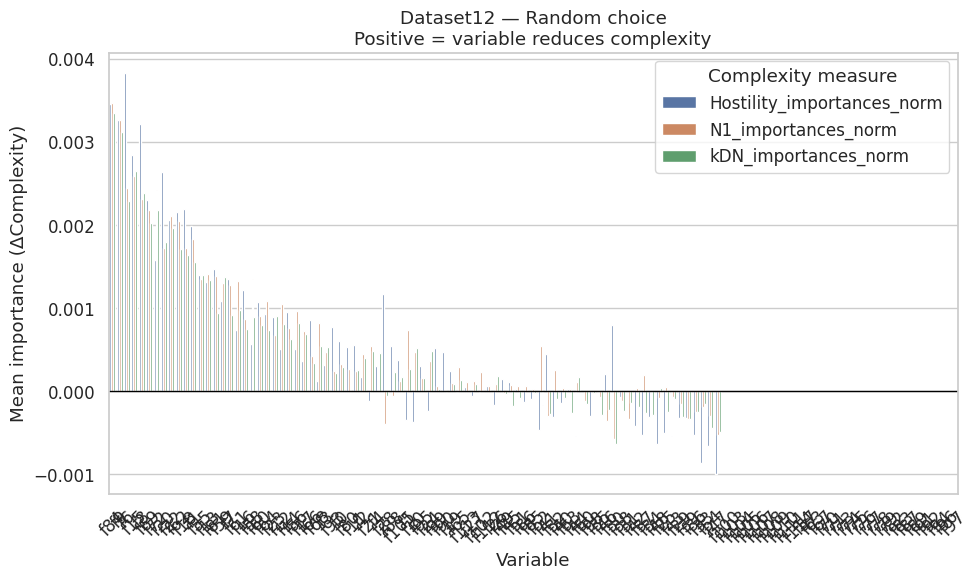

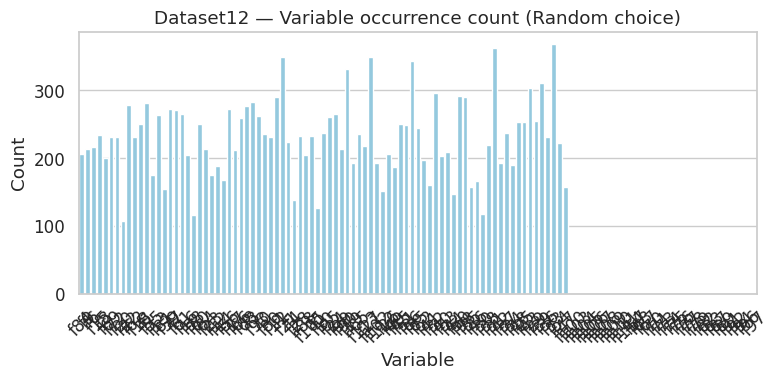

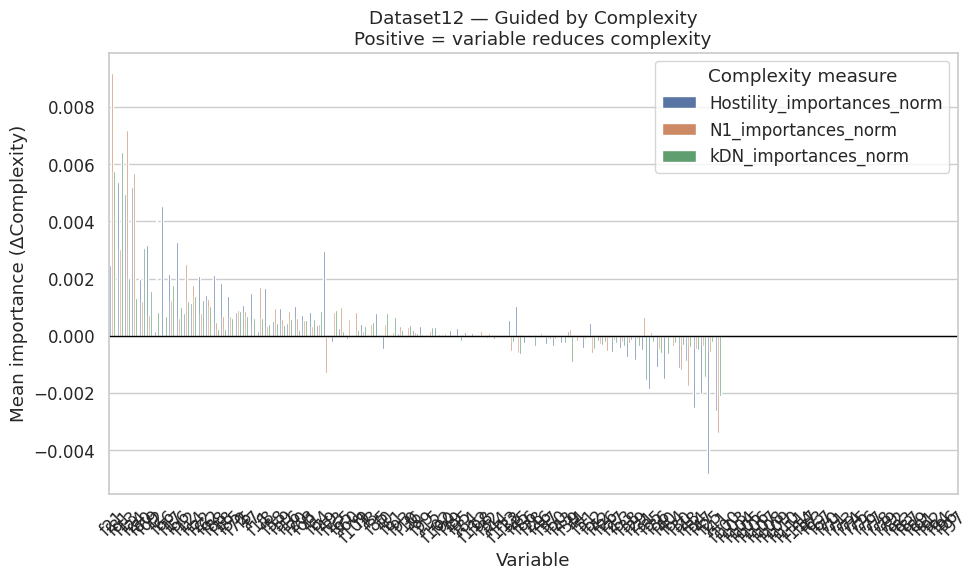

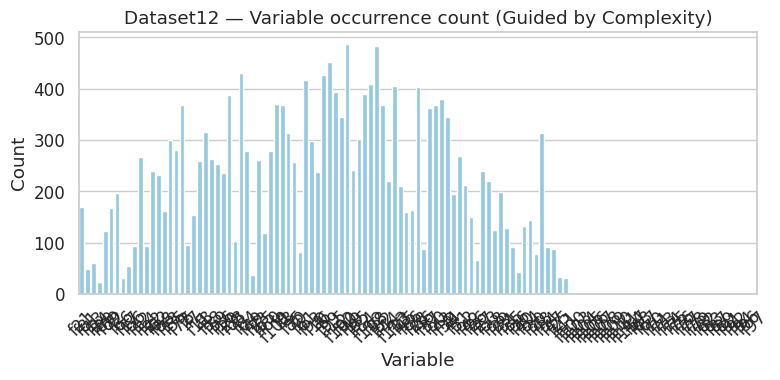

----------------- Spearman correlation random choice -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.693065,0.777633
N1_importances_norm,0.693065,1.000000,0.919189
kDN_importances_norm,0.777633,0.919189,1.000000


----------------- Spearman correlation complexity guided -----------------


,Hostility_importances_norm,N1_importances_norm,kDN_importances_norm
Hostility_importances_norm,1.000000,0.627409,0.695734
N1_importances_norm,0.627409,1.000000,0.837207
kDN_importances_norm,0.695734,0.837207,1.000000


In [9]:
# Dataset 12
df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset12_ComplexityRandomDistributed.csv", index_col=0)
df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset12_ComplexityGuidedDistributed.csv", index_col=0)


plot_complexity_importances(df_random, dataset_name="Dataset12", guided=False)
plot_complexity_importances(df_guided, dataset_name="Dataset12", guided=True)

corr_matrix = compute_spearman_correlations(df_random)
print('----------------- Spearman correlation random choice -----------------')
display(pd.DataFrame(corr_matrix))
corr_matrix_guided = compute_spearman_correlations(df_guided)
print('----------------- Spearman correlation complexity guided -----------------')
pd.DataFrame(corr_matrix_guided)

In [10]:
# # Dataset 14
# df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset14_ComplexityRandomDistributed.csv", index_col=0)
# df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset14_ComplexityGuidedDistributed.csv", index_col=0)
#
#
# plot_complexity_importances(df_random, dataset_name="Dataset14", guided=False)
# plot_complexity_importances(df_guided, dataset_name="Dataset14", guided=True)
#
# corr_matrix = compute_spearman_correlations(df_random)
# print('----------------- Spearman correlation random choice -----------------')
# display(pd.DataFrame(corr_matrix))
# corr_matrix_guided = compute_spearman_correlations(df_guided)
# print('----------------- Spearman correlation complexity guided -----------------')
# pd.DataFrame(corr_matrix_guided)

In [11]:
# # Dataset 16
# df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset16_ComplexityRandomDistributed.csv", index_col=0)
# df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset16_ComplexityGuidedDistributed.csv", index_col=0)
#
#
# plot_complexity_importances(df_random, dataset_name="Dataset16", guided=False)
# plot_complexity_importances(df_guided, dataset_name="Dataset16", guided=True)
#
# corr_matrix = compute_spearman_correlations(df_random)
# print('----------------- Spearman correlation random choice -----------------')
# display(pd.DataFrame(corr_matrix))
# corr_matrix_guided = compute_spearman_correlations(df_guided)
# print('----------------- Spearman correlation complexity guided -----------------')
# pd.DataFrame(corr_matrix_guided)

In [12]:
# # Dataset 17
# df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset17_ComplexityRandomDistributed.csv", index_col=0)
# df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset17_ComplexityGuidedDistributed.csv", index_col=0)
#
#
# plot_complexity_importances(df_random, dataset_name="Dataset17", guided=False)
# plot_complexity_importances(df_guided, dataset_name="Dataset17", guided=True)
#
# corr_matrix = compute_spearman_correlations(df_random)
# print('----------------- Spearman correlation random choice -----------------')
# display(pd.DataFrame(corr_matrix))
# corr_matrix_guided = compute_spearman_correlations(df_guided)
# print('----------------- Spearman correlation complexity guided -----------------')
# pd.DataFrame(corr_matrix_guided)

In [13]:
# # Dataset 18
# df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset18_ComplexityRandomDistributed.csv", index_col=0)
# df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset18_ComplexityGuidedDistributed.csv", index_col=0)
#
#
# plot_complexity_importances(df_random, dataset_name="Dataset18", guided=False)
# plot_complexity_importances(df_guided, dataset_name="Dataset18", guided=True)
#
# corr_matrix = compute_spearman_correlations(df_random)
# print('----------------- Spearman correlation random choice -----------------')
# display(pd.DataFrame(corr_matrix))
# corr_matrix_guided = compute_spearman_correlations(df_guided)
# print('----------------- Spearman correlation complexity guided -----------------')
# pd.DataFrame(corr_matrix_guided)

In [14]:
# # Dataset 19
# df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset19_ComplexityRandomDistributed.csv", index_col=0)
# df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset19_ComplexityGuidedDistributed.csv", index_col=0)
#
#
# plot_complexity_importances(df_random, dataset_name="Dataset19", guided=False)
# plot_complexity_importances(df_guided, dataset_name="Dataset19", guided=True)
#
# corr_matrix = compute_spearman_correlations(df_random)
# print('----------------- Spearman correlation random choice -----------------')
# display(pd.DataFrame(corr_matrix))
# corr_matrix_guided = compute_spearman_correlations(df_guided)
# print('----------------- Spearman correlation complexity guided -----------------')
# pd.DataFrame(corr_matrix_guided)

In [15]:
# # Dataset 20
# df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset20_ComplexityRandomDistributed.csv", index_col=0)
# df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset20_ComplexityGuidedDistributed.csv", index_col=0)
#
#
# plot_complexity_importances(df_random, dataset_name="Dataset20", guided=False)
# plot_complexity_importances(df_guided, dataset_name="Dataset20", guided=True)
#
# corr_matrix = compute_spearman_correlations(df_random)
# print('----------------- Spearman correlation random choice -----------------')
# display(pd.DataFrame(corr_matrix))
# corr_matrix_guided = compute_spearman_correlations(df_guided)
# print('----------------- Spearman correlation complexity guided -----------------')
# pd.DataFrame(corr_matrix_guided)

In [16]:
# # Dataset 21
# df_random = pd.read_csv("Results_FS_Distributed/ArtificialDataset21_ComplexityRandomDistributed.csv", index_col=0)
# df_guided = pd.read_csv("Results_FS_Distributed/ArtificialDataset21_ComplexityGuidedDistributed.csv", index_col=0)
#
#
# plot_complexity_importances(df_random, dataset_name="Dataset21", guided=False)
# plot_complexity_importances(df_guided, dataset_name="Dataset21", guided=True)
#
# corr_matrix = compute_spearman_correlations(df_random)
# print('----------------- Spearman correlation random choice -----------------')
# display(pd.DataFrame(corr_matrix))
# corr_matrix_guided = compute_spearman_correlations(df_guided)
# print('----------------- Spearman correlation complexity guided -----------------')
# pd.DataFrame(corr_matrix_guided)

## Tabla de comparación SOTA vs distributed (backward)

In [17]:
# Leer todos los comparison.csv de la carpeta
files = glob.glob("Results_ComparisonDistributed_SOTA/*_comparisonTable.csv")

all_tables = []
for f in files:
    df = pd.read_csv(f, index_col=[1])
    all_tables.append(df)

comparison_all = pd.concat(all_tables)
comparison_all.head()

,Dataset,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,...,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset11,0.105000,0.139200,0.061444,0.625549,0.336151,0.106733,0.469081,0.992561,0.994698,...,0.090419,0.857646,0.964681,0.093137,0.839063,0.945833,0.102299,0.881389,0.980000,0.126878
informative,ArtificialDataset11,0.057667,0.096600,0.174364,0.549833,0.274323,0.061933,0.442667,0.989020,0.994350,...,0.082885,0.877697,0.985046,0.088807,0.838646,0.980000,0.117334,0.915972,0.989444,0.063723
informative+redundant,ArtificialDataset11,0.066667,0.098067,0.080864,0.655375,0.292417,0.061163,0.439788,0.988041,0.993317,...,0.084417,0.878291,0.983309,0.090084,0.840729,0.978333,0.116382,0.915208,0.987778,0.069146
informative+redundant_nonLinear,ArtificialDataset11,0.092000,0.130200,0.082756,0.556537,0.367372,0.093408,0.449429,0.991863,0.994362,...,0.110298,0.854628,0.979814,0.113850,0.854375,0.972500,0.116122,0.866597,0.986111,0.166378
informative+noise,ArtificialDataset11,0.152333,0.216800,0.174364,0.583981,0.274573,0.181821,0.481774,0.996506,0.996025,...,0.067983,0.850266,0.948097,0.072646,0.800208,0.919167,0.089508,0.898542,0.971667,0.058451


In [18]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset2'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.096000,0.130800,0.102014,0.671750,0.247673,0.101082,0.423927,0.976896,0.984222,0.483732,18.000000,0.895750,0.963000,0.051294,0.895554,0.962990,0.051494,0.892750,0.952000,0.047796,0.898750,0.974000,0.057241
informative,0.078000,0.107400,0.088088,0.593333,0.249648,0.067752,0.402904,0.971353,0.983600,0.422721,10.000000,0.903375,0.977000,0.059416,0.903199,0.976996,0.059624,0.900250,0.970000,0.059833,0.906500,0.984000,0.060245
informative+redundant,0.087000,0.115200,0.105041,0.647500,0.264310,0.094810,0.402504,0.971571,0.982000,0.470010,14.000000,0.897125,0.971000,0.059415,0.896924,0.970991,0.059632,0.894250,0.962000,0.060563,0.900000,0.980000,0.060729
informative+redundant_nonLinear,0.069000,0.111200,0.023133,0.650182,0.245998,0.084667,0.404127,0.974451,0.984417,0.428464,12.000000,0.900875,0.971000,0.055743,0.900704,0.970993,0.055905,0.894500,0.964000,0.059663,0.907250,0.978000,0.052611
informative+noise,0.105000,0.137400,0.088088,0.597500,0.245478,0.090355,0.429860,0.979780,0.985583,0.450263,12.000000,0.897625,0.965000,0.053926,0.897434,0.964985,0.054132,0.892500,0.958000,0.052793,0.902750,0.972000,0.056223
informative+rand_extra,0.090000,0.126400,0.137654,0.598923,0.265848,0.096774,0.418381,0.976110,0.983154,0.470098,13.000000,0.893500,0.963000,0.057582,0.893353,0.962983,0.057714,0.889250,0.950000,0.056820,0.897750,0.976000,0.059985
mutual_info_top10,0.114000,0.179200,0.144307,0.399286,0.277373,0.164100,0.411188,0.981062,0.978300,0.141435,10.000000,0.856000,0.909000,0.043504,0.855590,0.908833,0.043626,0.876000,0.936000,0.048838,0.836000,0.890000,0.043134
f_classif_top10,0.131000,0.191400,0.195597,0.574923,0.282936,0.178617,0.422653,0.978922,0.980500,0.508600,10.000000,0.847125,0.898000,0.039873,0.846809,0.897706,0.039891,0.864500,0.932000,0.048494,0.829750,0.872000,0.033627
rf_top10,0.096000,0.128000,0.065991,0.634333,0.258633,0.110783,0.390631,0.961844,0.978300,0.057537,10.000000,0.873500,0.933000,0.051119,0.873251,0.932956,0.051305,0.876750,0.940000,0.054332,0.870250,0.926000,0.051641


In [19]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset3'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.050000,0.095000,0.128174,0.649000,0.161818,0.063008,0.458697,0.977972,0.989133,1.132809,45.000000,0.933875,0.985000,0.050456,0.933787,0.984994,0.050570,0.945250,0.994000,0.042988,0.922500,0.976000,0.059327
informative,0.056000,0.076800,0.004889,0.652923,0.140096,0.037496,0.445379,0.968942,0.986720,0.818155,25.000000,0.942500,0.993000,0.046736,0.942435,0.992999,0.046823,0.950000,0.994000,0.039799,0.935000,0.992000,0.054469
informative+redundant,0.043000,0.076600,0.007771,0.662077,0.129405,0.050861,0.445285,0.969741,0.987688,1.033983,32.000000,0.942500,0.992000,0.046944,0.942423,0.991998,0.047047,0.954750,0.992000,0.038202,0.930250,0.992000,0.056167
informative+redundant_nonLinear,0.042000,0.084600,0.065883,0.643846,0.178253,0.049119,0.449176,0.974485,0.988182,0.838673,33.000000,0.937125,0.988000,0.048994,0.937058,0.987997,0.049061,0.943000,0.994000,0.045103,0.931250,0.984000,0.053803
informative+noise,0.070000,0.100400,0.067468,0.653308,0.141118,0.072137,0.459966,0.977409,0.987700,0.815994,30.000000,0.937500,0.987000,0.049659,0.937437,0.986995,0.049756,0.943250,0.992000,0.045292,0.931750,0.982000,0.054368
informative+rand_extra,0.049000,0.081200,0.087372,0.630462,0.149967,0.051504,0.449929,0.973543,0.987464,0.835489,28.000000,0.938875,0.992000,0.048117,0.938790,0.991999,0.048234,0.947250,0.994000,0.041334,0.930500,0.990000,0.056364
mutual_info_top25,0.071000,0.105000,0.086882,0.628385,0.176572,0.088723,0.443005,0.969790,0.986640,1.020301,25.000000,0.929375,0.972000,0.044055,0.928990,0.971977,0.044708,0.951000,0.988000,0.035440,0.907750,0.958000,0.073098
f_classif_top25,0.101000,0.134400,0.104078,0.607385,0.186626,0.097306,0.447587,0.975521,0.986480,1.178811,25.000000,0.913000,0.956000,0.042068,0.912460,0.955976,0.042957,0.938500,0.970000,0.038851,0.887500,0.946000,0.073085
rf_top25,0.057000,0.093200,0.088500,0.640308,0.148828,0.078495,0.436126,0.967896,0.985840,0.993947,25.000000,0.936625,0.981000,0.041165,0.936536,0.980992,0.041234,0.947250,0.988000,0.038825,0.926000,0.974000,0.045969


In [20]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset7'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.027000,0.054400,0.052702,0.690917,0.148801,0.037635,0.445946,0.958892,0.986120,1.312835,50.000000,0.965500,0.994000,0.033848,0.965481,0.994000,0.033878,0.969750,0.996000,0.037863,0.961250,0.992000,0.030705
informative,0.008000,0.027200,0.047885,0.740700,0.067308,0.018279,0.411489,0.931018,0.981650,1.009091,20.000000,0.973875,0.999000,0.031466,0.973863,0.999000,0.031488,0.976500,1.000000,0.033205,0.971250,0.998000,0.030443
informative+redundant,0.014000,0.033000,0.011744,0.701182,0.097685,0.020969,0.413391,0.940088,0.983067,1.082760,30.000000,0.970375,1.000000,0.036485,0.970357,1.000000,0.036514,0.970750,1.000000,0.041182,0.970000,1.000000,0.032320
informative+redundant_nonLinear,0.015000,0.032000,0.049770,0.747700,0.137310,0.018700,0.416961,0.940200,0.983367,1.199497,30.000000,0.969500,0.996000,0.032413,0.969478,0.996000,0.032452,0.974250,0.998000,0.033881,0.964750,0.996000,0.031927
informative+noise,0.049000,0.062200,0.051221,0.658154,0.069280,0.048519,0.453899,0.968383,0.985967,1.013354,30.000000,0.971500,0.997000,0.029809,0.971481,0.997000,0.029843,0.974250,1.000000,0.031231,0.968750,0.994000,0.028843
informative+rand_extra,0.008000,0.031200,0.042871,0.714091,0.072162,0.020702,0.419714,0.941798,0.982391,1.141526,23.000000,0.973500,0.999000,0.030905,0.973485,0.999000,0.030935,0.977500,1.000000,0.030005,0.969500,0.998000,0.032262
mutual_info_top20,0.022000,0.043200,0.043262,0.753600,0.144102,0.038703,0.393945,0.928998,0.976150,0.917458,20.000000,0.960375,0.989000,0.040352,0.960251,0.988998,0.040568,0.976750,0.996000,0.031874,0.944000,0.984000,0.059059
f_classif_top20,0.024000,0.046400,0.003902,0.725600,0.093106,0.039335,0.396194,0.933647,0.976600,0.914243,20.000000,0.966875,0.990000,0.032982,0.966856,0.989999,0.033013,0.972500,0.994000,0.035193,0.961250,0.988000,0.032052
rf_top20,0.023000,0.035000,0.047594,0.746100,0.129881,0.033210,0.391093,0.930719,0.976550,1.148835,20.000000,0.963750,0.995000,0.039741,0.963636,0.994999,0.039935,0.978000,0.998000,0.035165,0.949500,0.992000,0.056828


In [21]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset8'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.129000,0.184000,0.195545,0.660833,0.290143,0.124608,0.478911,0.987986,0.991871,0.539881,85.000000,0.871000,0.962000,0.070488,0.870786,0.961934,0.070601,0.854750,0.942000,0.066004,0.887250,0.982000,0.077776
informative,0.053000,0.128000,0.206128,0.616000,0.224660,0.091075,0.468715,0.983293,0.991350,0.788417,40.000000,0.885875,0.985000,0.085678,0.885610,0.984993,0.086006,0.871000,0.976000,0.083173,0.900750,0.994000,0.089895
informative+redundant,0.068000,0.152000,0.160299,0.635000,0.259886,0.101738,0.469315,0.984918,0.991400,0.218165,55.000000,0.882000,0.981000,0.074187,0.881822,0.980992,0.074324,0.867250,0.974000,0.068594,0.896750,0.988000,0.082010
informative+redundant_nonLinear,0.094000,0.142000,0.193916,0.657929,0.282043,0.095126,0.470209,0.984890,0.991455,0.665166,55.000000,0.888500,0.983000,0.073807,0.888335,0.982991,0.073918,0.878500,0.972000,0.068692,0.898500,0.994000,0.079948
informative+noise,0.120000,0.180800,0.206128,0.616214,0.225714,0.118507,0.480132,0.989130,0.992000,0.798303,55.000000,0.875250,0.969000,0.076701,0.874998,0.968981,0.076835,0.861250,0.954000,0.075585,0.889250,0.984000,0.080916
informative+rand_extra,0.071000,0.131200,0.206128,0.615857,0.251437,0.086931,0.469220,0.983671,0.991442,0.804831,43.000000,0.880125,0.984000,0.088850,0.878482,0.983992,0.091081,0.847750,0.974000,0.124269,0.912500,0.994000,0.086947
mutual_info_top40,0.171000,0.224400,0.146686,0.717000,0.285754,0.189818,0.472984,0.987705,0.990525,0.103143,40.000000,0.854625,0.915000,0.054356,0.854335,0.914815,0.054488,0.834500,0.892000,0.049451,0.874750,0.948000,0.065639
f_classif_top40,0.166000,0.218000,0.181005,0.517067,0.295342,0.191840,0.472983,0.987842,0.991000,0.996513,40.000000,0.847375,0.918000,0.054560,0.846775,0.917891,0.055091,0.835000,0.892000,0.040469,0.859750,0.944000,0.087632
rf_top40,0.121000,0.182400,0.084212,0.599923,0.290086,0.150197,0.467276,0.984910,0.990300,0.975738,40.000000,0.867875,0.941000,0.060563,0.867551,0.940902,0.060711,0.843250,0.920000,0.055156,0.892500,0.972000,0.069765


In [22]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset10'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.144000,0.160100,0.149454,0.550658,0.317714,0.160810,0.455342,0.982259,0.991197,0.906692,61.000000,0.870875,0.912000,0.041100,0.832287,0.886961,0.046553,0.705625,0.778333,0.041211,0.941696,0.990714,0.056295
informative,0.079500,0.125100,0.159981,0.575167,0.280286,0.119875,0.364366,0.970477,0.988167,0.665170,6.000000,0.885375,0.926500,0.039192,0.846762,0.903675,0.057514,0.712708,0.800000,0.091880,0.959375,0.993571,0.033902
informative+redundant,0.090500,0.139100,0.144569,0.527972,0.321964,0.118967,0.389214,0.976058,0.987731,1.027539,26.000000,0.879188,0.919500,0.049207,0.844673,0.898795,0.055229,0.728542,0.813333,0.058448,0.943750,0.990000,0.067683
informative+redundant_nonLinear,0.108000,0.140100,0.118037,0.631938,0.315713,0.122586,0.392545,0.977392,0.989571,0.434663,21.000000,0.877375,0.912500,0.038657,0.838772,0.881699,0.051531,0.710833,0.786667,0.062259,0.948750,0.993571,0.039013
informative+noise,0.229000,0.286000,0.159981,0.622687,0.280023,0.264936,0.483063,0.996408,0.994577,0.670839,26.000000,0.852750,0.905000,0.042451,0.793995,0.878586,0.069522,0.627500,0.771667,0.102821,0.949286,0.989286,0.040073
informative+rand_extra,0.088500,0.127400,0.165385,0.517437,0.335485,0.116308,0.368267,0.973692,0.987722,0.666963,9.000000,0.876563,0.920500,0.050398,0.824050,0.894107,0.101544,0.678333,0.798333,0.153282,0.961518,0.994286,0.029046
mutual_info_top6,0.147000,0.224400,0.213949,0.389937,0.300827,0.221017,0.409616,0.990258,0.988833,0.653762,6.000000,0.830750,0.858000,0.025860,0.775208,0.815461,0.029647,0.637708,0.705000,0.047400,0.913482,0.955000,0.040150
f_classif_top6,0.147000,0.212400,0.223497,0.555088,0.300808,0.215575,0.399183,0.987780,0.986250,1.359141,6.000000,0.811750,0.847500,0.030554,0.749237,0.790537,0.043338,0.617708,0.688333,0.071741,0.894911,0.947857,0.042113
rf_top6,0.111000,0.151900,0.179426,0.428636,0.255337,0.144058,0.352852,0.974198,0.991500,0.634135,6.000000,0.873500,0.894000,0.025348,0.834459,0.863071,0.028476,0.706875,0.755000,0.046346,0.944911,0.987857,0.041528


In [23]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset11'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.105000,0.139200,0.061444,0.625549,0.336151,0.106733,0.469081,0.992561,0.994698,0.504040,75.000000,0.864458,0.966333,0.090419,0.857646,0.964681,0.093137,0.839063,0.945833,0.102299,0.881389,0.980000,0.126878
informative,0.057667,0.096600,0.174364,0.549833,0.274323,0.061933,0.442667,0.989020,0.994350,0.571514,20.000000,0.885042,0.985667,0.082885,0.877697,0.985046,0.088807,0.838646,0.980000,0.117334,0.915972,0.989444,0.063723
informative+redundant,0.066667,0.098067,0.080864,0.655375,0.292417,0.061163,0.439788,0.988041,0.993317,0.540162,40.000000,0.885417,0.984000,0.084417,0.878291,0.983309,0.090084,0.840729,0.978333,0.116382,0.915208,0.987778,0.069146
informative+redundant_nonLinear,0.092000,0.130200,0.082756,0.556537,0.367372,0.093408,0.449429,0.991863,0.994362,0.505634,35.000000,0.861708,0.980667,0.110298,0.854628,0.979814,0.113850,0.854375,0.972500,0.116122,0.866597,0.986111,0.166378
informative+noise,0.152333,0.216800,0.174364,0.583981,0.274573,0.181821,0.481774,0.996506,0.996025,0.574145,40.000000,0.859208,0.950667,0.067983,0.850266,0.948097,0.072646,0.800208,0.919167,0.089508,0.898542,0.971667,0.058451
informative+rand_extra,0.082667,0.094533,0.176317,0.523877,0.309336,0.066025,0.441935,0.988337,0.994043,0.565375,23.000000,0.879250,0.984000,0.088040,0.872433,0.983306,0.092899,0.845104,0.977500,0.113887,0.902014,0.988333,0.088955
mutual_info_top20,0.139333,0.194533,0.110375,0.529877,0.329754,0.169764,0.450809,0.993806,0.990667,0.342375,20.000000,0.828375,0.922333,0.073379,0.819450,0.918068,0.074932,0.800833,0.925000,0.091437,0.846736,0.946111,0.120936
f_classif_top20,0.103333,0.178133,0.096553,0.635583,0.333745,0.154507,0.449857,0.992941,0.991550,0.628668,20.000000,0.844458,0.950333,0.076429,0.835004,0.947700,0.081178,0.788021,0.916667,0.093913,0.882083,0.972778,0.072752
rf_top20,0.109667,0.142533,0.187803,0.564510,0.276387,0.117806,0.440804,0.989752,0.990933,0.349706,20.000000,0.863708,0.952667,0.069253,0.853775,0.950050,0.075433,0.792813,0.915833,0.098492,0.910972,0.977222,0.051285


In [24]:
display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset12'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,
all,0.182333,0.262467,0.292444,0.534960,0.392270,0.246505,0.486406,0.997126,0.997551,0.781137,115.000000,0.798417,0.872000,0.064805,0.786513,0.866020,0.069523,0.711129,0.806686,0.074738,0.861372,0.919084,0.063950
informative,0.143000,0.234333,0.278586,0.535712,0.346237,0.213641,0.474360,0.996675,0.997480,0.482905,25.000000,0.815792,0.886333,0.060785,0.806226,0.881656,0.063539,0.737262,0.834533,0.067979,0.872400,0.923668,0.061856
informative+redundant,0.145667,0.244000,0.298350,0.422258,0.361075,0.223381,0.475779,0.996955,0.997461,0.563607,55.000000,0.814875,0.884000,0.061854,0.805674,0.879135,0.064005,0.738863,0.830552,0.063095,0.869672,0.922522,0.066122
informative+redundant_nonLinear,0.135000,0.249533,0.336279,0.533470,0.401650,0.239003,0.477403,0.996886,0.997358,0.552386,55.000000,0.801167,0.878667,0.068905,0.787177,0.873335,0.078844,0.709559,0.820203,0.097317,0.867258,0.920798,0.061725
informative+noise,0.203667,0.309533,0.322540,0.525551,0.349617,0.292228,0.491331,0.998033,0.997770,0.498972,55.000000,0.797083,0.866000,0.057765,0.785800,0.859003,0.059797,0.707145,0.787606,0.054793,0.861931,0.922525,0.063570
informative+rand_extra,0.147667,0.235800,0.276547,0.573550,0.352342,0.216239,0.476667,0.996758,0.997536,0.467870,28.000000,0.815167,0.884667,0.060712,0.805536,0.879818,0.063271,0.735375,0.830552,0.065220,0.872686,0.923665,0.063364
mutual_info_top25,0.189000,0.301533,0.272266,0.623907,0.387758,0.298432,0.476449,0.997531,0.997080,0.690632,25.000000,0.774208,0.836667,0.049619,0.759195,0.827648,0.053980,0.671874,0.750210,0.065015,0.848020,0.898989,0.052659
f_classif_top25,0.221667,0.303733,0.276931,0.534889,0.380682,0.284980,0.472131,0.997390,0.996773,0.452094,25.000000,0.767583,0.828000,0.046664,0.754479,0.817127,0.047543,0.675911,0.728711,0.043631,0.833658,0.902440,0.059226
rf_top25,0.180333,0.299667,0.282076,0.566650,0.392885,0.293268,0.471664,0.997337,0.996947,0.576730,25.000000,0.769750,0.828000,0.049101,0.752969,0.817312,0.056500,0.660927,0.735860,0.079041,0.848241,0.900141,0.048407


In [25]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset14'].iloc[:,1:].style.background_gradient(cmap="viridis"))

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,n_features,mean_acc_mean,mean_acc_max,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,,,


In [ ]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset16'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [ ]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset17'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [ ]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset18'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [ ]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset19'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [ ]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset20'].iloc[:,1:].style.background_gradient(cmap="viridis"))

In [ ]:
# display(comparison_all.loc[comparison_all['Dataset']=='ArtificialDataset21'].iloc[:,1:].style.background_gradient(cmap="viridis"))